In [1]:
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import useful_rdkit_utils as uru
from rdkit import DataStructs
from tqdm.auto import tqdm
from lightgbm import LGBMRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

In [2]:
tqdm.pandas()

In [3]:
train_df         = pd.read_csv("hf://datasets/openadmet/pxr-challenge-train-test/pxr-challenge_TRAIN.csv")
test_df          = pd.read_csv("hf://datasets/openadmet/pxr-challenge-train-test/pxr-challenge_TEST_BLINDED.csv")
train_counter_df = pd.read_csv("hf://datasets/openadmet/pxr-challenge-train-test/pxr-challenge_counter-assay_TRAIN.csv")
train_single_df  = pd.read_csv("hf://datasets/openadmet/pxr-challenge-train-test/pxr-challenge_single_concentration_TRAIN.csv")

# Data Processing

In [4]:
# Select the relevant columns
keep_cols = [
    "Molecule Name", "SMILES", "pEC50",
    "pEC50_std.error (-log10(molarity))",
    "pEC50_ci.lower (-log10(molarity))",
    "pEC50_ci.upper (-log10(molarity))",
    "Emax_estimate (log2FC vs. baseline)",
    "Emax.vs.pos.ctrl_estimate (dimensionless)",
    "Split",
]
model_df = train_df[keep_cols].copy()

# Use shorter column names for convenience
model_df = model_df.rename(columns={
    "pEC50_std.error (-log10(molarity))": "pEC50_std_error",
    "pEC50_ci.lower (-log10(molarity))":  "pEC50_ci_lower",
    "pEC50_ci.upper (-log10(molarity))":  "pEC50_ci_upper",
    "Emax_estimate (log2FC vs. baseline)":         "Emax",
    "Emax.vs.pos.ctrl_estimate (dimensionless)":   "Emax_vs_ctrl",
})
model_df.head()

,Molecule Name,SMILES,pEC50,pEC50_std_error,pEC50_ci_lower,pEC50_ci_upper,Emax,Emax_vs_ctrl,Split
0,OADMET-0006089,CC1C2CCCCC2CN1C(=O)C1=CC(F)=CC2=C1CNCC2,5.27,0.0620,5.148480,5.391520,1.67,0.539,Train
1,OADMET-0006088,CN(C(=O)C1=CC=CC=C1SCC(=O)N1CCC2=CC=CC=C21)C1C...,5.08,0.0870,4.909480,5.250520,1.70,0.491,Train
2,OADMET-0006087,O=C(C1CCCC1)N1CC(S(=O)(=O)NC2CC2C2=C(F)C=CC=C2...,5.12,0.1660,4.794640,5.445360,1.88,0.663,Train
3,OADMET-0006086,CC1CN(C(=O)C2=CC=CC(C3=C(F)C=CC=C3F)=C2)CCN1C1...,5.23,0.1120,5.010480,5.449520,2.20,0.889,Train
4,OADMET-0006085,CC1(C2=NOC(C3=NN(CC4=CC=C(F)C=C4)C(=O)CC3)=N2)...,5.28,0.0466,5.188664,5.371336,1.82,0.623,Train


In [12]:
model_df.iloc[0]

Molecule Name                               OADMET-0006089
SMILES             CC1C2CCCCC2CN1C(=O)C1=CC(F)=CC2=C1CNCC2
pEC50                                                 5.27
pEC50_std_error                                      0.062
pEC50_ci_lower                                     5.14848
pEC50_ci_upper                                     5.39152
Emax                                                  1.67
Emax_vs_ctrl                                         0.539
Split                                                Train
Name: 0, dtype: object

# Train

## Simple GP on RDKit Descriptors

In [5]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [14]:
rdkit_desc = uru.RDKitDescriptors()

In [131]:
train_pec50 = model_df.dropna(subset=["pEC50"]).copy()
print(f"Compounds with valid pEC50: {len(train_pec50)}")

train_pec50["descriptors"] = [rdkit_desc.calc_smiles(x) for x in tqdm(train_pec50.SMILES)]

Compounds with valid pEC50: 4139


  0%|          | 0/4139 [00:00<?, ?it/s]

In [99]:
train, test = train_test_split(train_pec50)

In [108]:
y_train = train["pEC50"]
x_train = np.stack(train.descriptors)

y_test = test["pEC50"]
x_test = np.stack(test.descriptors)

In [ ]:
x_scaler = StandardScaler()
x_train_s = x_scaler.fit_transform(x_train)
x_test_s  = x_scaler.transform(x_test)

y_scaler = StandardScaler()
y_train_s = y_scaler.fit_transform(y_train.to_numpy().reshape(-1,1)).ravel()
y_test_s = y_scaler.fit_transform(y_test.to_numpy().reshape(-1,1)).ravel()

In [134]:
mask_tr = ~np.isnan(x_train_s).any(axis=1)   # True for rows with no NaNs
x_train_s = x_train_s[mask_tr]
y_train = y_train[mask_tr]

mask_te = ~np.isnan(x_test_s).any(axis=1)   # True for rows with no NaNs
x_test = x_test[mask_te]
y_test = y_test[mask_te]
x_test_s = x_test_s[mask_te]
y_test_s = y_test_s[mask_te]

In [135]:
kernel = 1.0 * RBF(length_scale=100, length_scale_bounds=(1e-3, 1e6)) + WhiteKernel(
    noise_level=1, noise_level_bounds=(1e-10, 1e1)
)
gpr = GaussianProcessRegressor(kernel=kernel, alpha=0.0)
gpr.fit(x_train_s, y_train)

,"kernel kernel: kernel instance, default=NoneThe kernel specifying the covariance function of the GP. If None ispassed, the kernel ``ConstantKernel(1.0, constant_value_bounds=""fixed"")* RBF(1.0, length_scale_bounds=""fixed"")`` is used as default. Note thatthe kernel hyperparameters are optimized during fitting unless thebounds are marked as ""fixed"".",1**2 * RBF(le...noise_level=1)
,"alpha alpha: float or ndarray of shape (n_samples,), default=1e-10Value added to the diagonal of the kernel matrix during fitting.This can prevent a potential numerical issue during fitting, byensuring that the calculated values form a positive definite matrix.It can also be interpreted as the variance of additional Gaussianmeasurement noise on the training observations. Note that this isdifferent from using a `WhiteKernel`. If an array is passed, it musthave the same number of entries as the data used for fitting and isused as datapoint-dependent noise level. Allowing to specify thenoise level directly as a parameter is mainly for convenience andfor consistency with :class:`~sklearn.linear_model.Ridge`.For an example illustrating how the alpha parameter controlsthe noise variance in Gaussian Process Regression, see:ref:`sphx_glr_auto_examples_gaussian_process_plot_gpr_noisy_targets.py`.",0.0
,"optimizer optimizer: ""fmin_l_bfgs_b"", callable or None, default=""fmin_l_bfgs_b""Can either be one of the internally supported optimizers for optimizingthe kernel's parameters, specified by a string, or an externallydefined optimizer passed as a callable. If a callable is passed, itmust have the signature:: def optimizer(obj_func, initial_theta, bounds): # * 'obj_func': the objective function to be minimized, which # takes the hyperparameters theta as a parameter and an # optional flag eval_gradient, which determines if the # gradient is returned additionally to the function value # * 'initial_theta': the initial value for theta, which can be # used by local optimizers # * 'bounds': the bounds on the values of theta .... # Returned are the best found hyperparameters theta and # the corresponding value of the target function. return theta_opt, func_minPer default, the L-BFGS-B algorithm from `scipy.optimize.minimize`is used. If None is passed, the kernel's parameters are kept fixed.Available internal optimizers are: `{'fmin_l_bfgs_b'}`.",'fmin_l_bfgs_b'
,"n_restarts_optimizer n_restarts_optimizer: int, default=0The number of restarts of the optimizer for finding the kernel'sparameters which maximize the log-marginal likelihood. The first runof the optimizer is performed from the kernel's initial parameters,the remaining ones (if any) from thetas sampled log-uniform randomlyfrom the space of allowed theta-values. If greater than 0, all boundsmust be finite. Note that `n_restarts_optimizer == 0` implies that onerun is performed.",0
,"normalize_y normalize_y: bool, default=FalseWhether or not to normalize the target values `y` by removing the meanand scaling to unit-variance. This is recommended for cases wherezero-mean, unit-variance priors are used. Note that, in thisimplementation, the normalisation is reversed before the GP predictionsare reported... versionchanged:: 0.23",False
,"copy_X_train copy_X_train: bool, default=TrueIf True, a persistent copy of the training data is stored in theobject. Otherwise, just a reference to the training data is stored,which might cause predictions to change if the data is modifiedexternally.",True
,"n_targets n_targets: int, default=NoneThe number of dimensions of the target values. Used to decide the numberof outputs when sampling from the prior distributions (i.e. calling:meth:`sample_y` before :meth:`fit`). This parameter is ignored once:meth:`fit` has been called... versionadded:: 1.3",None
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation used to initialize the centers.Pass an int for reproducible results across multiple function calls.See :term:`Glo

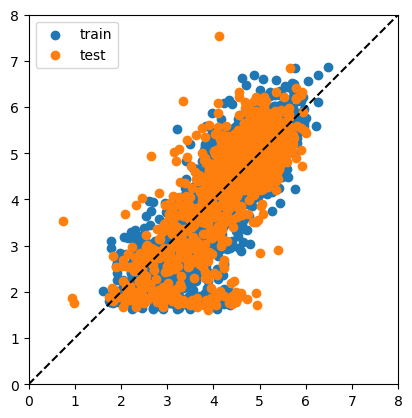

[0.727239943459888, 0.5808536161926545]

In [139]:
y_mean_tr, y_std_tr = gpr.predict(x_train_s, return_std=True)
y_mean_te, y_std_te = gpr.predict(x_test_s, return_std=True)

plt.scatter( y_mean_tr, y_train , label='train')
plt.scatter( y_mean_te, y_test , label='test')
plt.plot([0,8],[0,8], linestyle='--', c='k')
plt.xlim(0,8)
plt.ylim(0,8)
plt.gca().set_aspect('equal')
plt.legend()
plt.show()

[r2_score(y_train, y_mean_tr), r2_score(y_test, y_mean_te)]

## On PCA of RDKit 

In [129]:
from sklearn.decomposition import PCA

In [135]:
train, test = train_test_split(train_pec50)

In [176]:
x_scaler = StandardScaler()
x_train_s = x_scaler.fit_transform(np.stack(train.descriptors))
x_test_s  = x_scaler.transform(np.stack(test.descriptors))

mask_tr = ~np.isnan(x_train_s).any(axis=1)   # True for rows with no NaNs
x_train_s = x_train_s[mask_tr]
y_train = train["pEC50"][mask_tr]

y_test = test["pEC50"]
mask_te = ~np.isnan(x_test_s).any(axis=1)   # True for rows with no NaNs
x_test_s = x_test_s[mask_te]
y_test = y_test[mask_te]

In [194]:
pca_x = PCA(n_components=len(x_test_s[0]))
pca_x.fit(x_train_s)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",217
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized SV

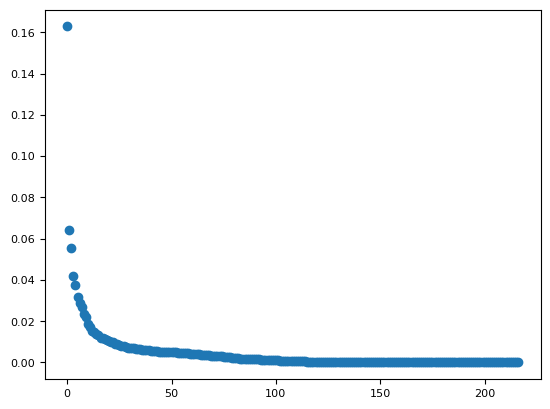

In [195]:
plt.scatter(np.arange(len(x_test_s[0])), pca_x.explained_variance_ratio_)

In [196]:
pca_x = PCA(n_components=100)
pca_x.fit(x_train_s)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",100
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized SV

In [197]:
kernel = 1.0 * RBF(length_scale=100, length_scale_bounds=(1e-3, 1e6)) + WhiteKernel(
    noise_level=1, noise_level_bounds=(1e-10, 1e1)
)
gpr = GaussianProcessRegressor(kernel=kernel, alpha=0.0)
gpr.fit(pca_x.transform(x_train_s), y_train)

,"kernel kernel: kernel instance, default=NoneThe kernel specifying the covariance function of the GP. If None ispassed, the kernel ``ConstantKernel(1.0, constant_value_bounds=""fixed"")* RBF(1.0, length_scale_bounds=""fixed"")`` is used as default. Note thatthe kernel hyperparameters are optimized during fitting unless thebounds are marked as ""fixed"".",1**2 * RBF(le...noise_level=1)
,"alpha alpha: float or ndarray of shape (n_samples,), default=1e-10Value added to the diagonal of the kernel matrix during fitting.This can prevent a potential numerical issue during fitting, byensuring that the calculated values form a positive definite matrix.It can also be interpreted as the variance of additional Gaussianmeasurement noise on the training observations. Note that this isdifferent from using a `WhiteKernel`. If an array is passed, it musthave the same number of entries as the data used for fitting and isused as datapoint-dependent noise level. Allowing to specify thenoise level directly as a parameter is mainly for convenience andfor consistency with :class:`~sklearn.linear_model.Ridge`.For an example illustrating how the alpha parameter controlsthe noise variance in Gaussian Process Regression, see:ref:`sphx_glr_auto_examples_gaussian_process_plot_gpr_noisy_targets.py`.",0.0
,"optimizer optimizer: ""fmin_l_bfgs_b"", callable or None, default=""fmin_l_bfgs_b""Can either be one of the internally supported optimizers for optimizingthe kernel's parameters, specified by a string, or an externallydefined optimizer passed as a callable. If a callable is passed, itmust have the signature:: def optimizer(obj_func, initial_theta, bounds): # * 'obj_func': the objective function to be minimized, which # takes the hyperparameters theta as a parameter and an # optional flag eval_gradient, which determines if the # gradient is returned additionally to the function value # * 'initial_theta': the initial value for theta, which can be # used by local optimizers # * 'bounds': the bounds on the values of theta .... # Returned are the best found hyperparameters theta and # the corresponding value of the target function. return theta_opt, func_minPer default, the L-BFGS-B algorithm from `scipy.optimize.minimize`is used. If None is passed, the kernel's parameters are kept fixed.Available internal optimizers are: `{'fmin_l_bfgs_b'}`.",'fmin_l_bfgs_b'
,"n_restarts_optimizer n_restarts_optimizer: int, default=0The number of restarts of the optimizer for finding the kernel'sparameters which maximize the log-marginal likelihood. The first runof the optimizer is performed from the kernel's initial parameters,the remaining ones (if any) from thetas sampled log-uniform randomlyfrom the space of allowed theta-values. If greater than 0, all boundsmust be finite. Note that `n_restarts_optimizer == 0` implies that onerun is performed.",0
,"normalize_y normalize_y: bool, default=FalseWhether or not to normalize the target values `y` by removing the meanand scaling to unit-variance. This is recommended for cases wherezero-mean, unit-variance priors are used. Note that, in thisimplementation, the normalisation is reversed before the GP predictionsare reported... versionchanged:: 0.23",False
,"copy_X_train copy_X_train: bool, default=TrueIf True, a persistent copy of the training data is stored in theobject. Otherwise, just a reference to the training data is stored,which might cause predictions to change if the data is modifiedexternally.",True
,"n_targets n_targets: int, default=NoneThe number of dimensions of the target values. Used to decide the numberof outputs when sampling from the prior distributions (i.e. calling:meth:`sample_y` before :meth:`fit`). This parameter is ignored once:meth:`fit` has been called... versionadded:: 1.3",None
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation used to initialize the centers.Pass an int for reproducible results across multiple function calls.See :term:`Glo

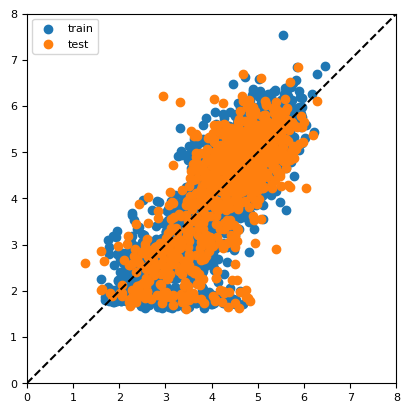

[0.6819467043882945, 0.5577729692380176]

In [198]:
y_mean_tr, y_std_tr = gpr.predict(pca_x.transform(x_train_s), return_std=True)
y_mean_te, y_std_te = gpr.predict(pca_x.transform(x_test_s), return_std=True)

plt.scatter( y_mean_tr, y_train , label='train')
plt.scatter( y_mean_te, y_test , label='test')
plt.plot([0,8],[0,8], linestyle='--', c='k')
plt.xlim(0,8)
plt.ylim(0,8)
plt.gca().set_aspect('equal')
plt.legend()
plt.show()

[r2_score(y_train, y_mean_tr), r2_score(y_test, y_mean_te)]

# GNN Embedding + MLP Regression

In [6]:
# Select the relevant columns
keep_cols = [
    "Molecule Name", "SMILES", "pEC50",
    "pEC50_std.error (-log10(molarity))",
    "pEC50_ci.lower (-log10(molarity))",
    "pEC50_ci.upper (-log10(molarity))",
    "Emax_estimate (log2FC vs. baseline)",
    "Emax.vs.pos.ctrl_estimate (dimensionless)",
    "Split",
]
model_df = train_df[keep_cols].copy()

# Use shorter column names for convenience
model_df = model_df.rename(columns={
    "pEC50_std.error (-log10(molarity))": "pEC50_std_error",
    "pEC50_ci.lower (-log10(molarity))":  "pEC50_ci_lower",
    "pEC50_ci.upper (-log10(molarity))":  "pEC50_ci_upper",
    "Emax_estimate (log2FC vs. baseline)":         "Emax",
    "Emax.vs.pos.ctrl_estimate (dimensionless)":   "Emax_vs_ctrl",
})

In [7]:
train_pec50 = model_df.dropna(subset=["pEC50"]).copy()
train, test = train_test_split(train_pec50)

In [13]:
test_df.to_csv('blind_test.csv')

In [6]:
import torch
from torch.utils.data import Dataset
from torch_geometric.data import Data
from rdkit import Chem

def atom_features(atom):
    return [
        atom.GetAtomicNum(),
        atom.GetDegree(),
        atom.GetFormalCharge(),
        int(atom.GetHybridization()),
        int(atom.GetIsAromatic()),
        atom.GetTotalNumHs(),
    ]

def bond_features(bond):
    bt = bond.GetBondType()
    return [
        int(bt == Chem.rdchem.BondType.SINGLE),
        int(bt == Chem.rdchem.BondType.DOUBLE),
        int(bt == Chem.rdchem.BondType.TRIPLE),
        int(bt == Chem.rdchem.BondType.AROMATIC),
        int(bond.GetIsConjugated()),
        int(bond.IsInRing()),
    ]

class MoleculeDataset(Dataset):
    def __init__(self, smiles, targets):
        self.smiles = smiles
        self.targets = targets

    def __len__(self):
        return len(self.smiles)

    def __getitem__(self, idx):
        mol = Chem.MolFromSmiles(self.smiles[idx])

        x = torch.tensor(
            [atom_features(a) for a in mol.GetAtoms()],
            dtype=torch.float
        )

        edge_index = []
        edge_attr = []

        for bond in mol.GetBonds():
            i = bond.GetBeginAtomIdx()
            j = bond.GetEndAtomIdx()
            bf = bond_features(bond)

            edge_index += [[i, j], [j, i]]
            edge_attr += [bf, bf]

        edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
        edge_attr = torch.tensor(edge_attr, dtype=torch.float)

        y = torch.tensor(self.targets[idx], dtype=torch.float)

        return Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y)

In [7]:
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GINEConv, global_mean_pool

class MoleculeGNN(nn.Module):
    def __init__(self, node_dim, edge_dim, hidden_dim=64, num_layers=2):
        super().__init__()

        self.node_embed = nn.Linear(node_dim, hidden_dim)
        self.edge_embed = nn.Linear(edge_dim, hidden_dim)

        self.convs = nn.ModuleList()
        self.norms = nn.ModuleList()

        for _ in range(num_layers):
            mlp = nn.Sequential(
                nn.Linear(hidden_dim, hidden_dim),
                nn.ReLU(),
                nn.Linear(hidden_dim, hidden_dim)
            )
            self.convs.append(GINEConv(mlp))
            self.norms.append(nn.LayerNorm(hidden_dim))

        self.readout = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, x, edge_index, batch, edge_attr):
        # embed
        x = self.node_embed(x)
        edge_attr = self.edge_embed(edge_attr)

        # message passing
        for conv, norm in zip(self.convs, self.norms):
            h = conv(x, edge_index, edge_attr)
            x = x + norm(F.relu(h))  # residual

        # graph embedding
        g = global_mean_pool(x, batch)

        # regression
        out = self.readout(g).squeeze()

        return out, g  # return embedding too

In [10]:
from torch_geometric.loader import DataLoader
from torch.utils.data import random_split

dataset = MoleculeDataset(np.stack(train.SMILES), np.stack(train.pEC50))

train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

In [73]:
blind_test_dataset = MoleculeDataset(np.stack(test_df.SMILES),np.zeros(len(test_df), dtype=float))
blind_test_loader = DataLoader(blind_test_dataset, batch_size=1)

In [ ]:
def get_preds(model, loader):
    model.eval()

    preds = []
    targets = []

    with torch.no_grad():
        for batch in loader:
            pred, _ = model(
                batch.x,
                batch.edge_index,
                batch.batch,
                batch.edge_attr
            )

            preds.append(pred.reshape(-1).cpu())   # <-- FIX
            targets.append(batch.y.view(-1).cpu())

    preds = torch.cat(preds).numpy()
    targets = torch.cat(targets).numpy()

    return targets, preds

In [ ]:
model = MoleculeGNN(node_dim=6, edge_dim=6)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

num_epochs = 200
for epoch in range(num_epochs):

    # -------------------
    # TRAIN
    # -------------------
    model.train()

    train_preds = []
    train_targets = []
    train_loss_sum = 0.0

    for batch in train_loader:
        optimizer.zero_grad()

        pred, emb = model(
            batch.x,
            batch.edge_index,
            batch.batch,
            batch.edge_attr
        )

        loss = loss_fn(pred, batch.y.view(-1))
        loss.backward()
        optimizer.step()

        train_loss_sum += loss.item()

        train_preds.append(pred.detach().cpu())
        train_targets.append(batch.y.view(-1).cpu())

    train_preds = torch.cat(train_preds)
    train_targets = torch.cat(train_targets)

    train_mse = torch.mean((train_preds - train_targets) ** 2).item()
    train_r2 = r2_score(train_targets.numpy(), train_preds.numpy())

    # -------------------
    # TEST
    # -------------------
    model.eval()

    test_preds = []
    test_targets = []

    with torch.no_grad():
        for batch in test_loader:
            pred, _ = model(
                batch.x,
                batch.edge_index,
                batch.batch,
                batch.edge_attr
            )

            test_preds.append(pred.cpu())
            test_targets.append(batch.y.view(-1).cpu())

    test_preds = torch.cat(test_preds)
    test_targets = torch.cat(test_targets)

    test_mse = torch.mean((test_preds - test_targets) ** 2).item()
    test_r2 = r2_score(test_targets.numpy(), test_preds.numpy())


    # -------------------
    # PRINT
    # -------------------
    print(f"""
Epoch {epoch:03d}
-----------------------------
Train Loss : {train_loss_sum / len(train_loader):.6f}
Train MSE  : {train_mse:.6f}
Train R²   : {train_r2:.4f}

Test  MSE  : {test_mse:.6f}
Test  R²   : {test_r2:.4f}
""")


Epoch 000
-----------------------------
Train Loss : 2.172667
Train MSE  : 2.178267
Train R²   : -0.7413

Test  MSE  : 1.301484
Test  R²   : -0.0085


Epoch 001
-----------------------------
Train Loss : 1.274487
Train MSE  : 1.272326
Train R²   : -0.0171

Test  MSE  : 1.294692
Test  R²   : -0.0032


Epoch 002
-----------------------------
Train Loss : 1.255389
Train MSE  : 1.257643
Train R²   : -0.0053

Test  MSE  : 1.306011
Test  R²   : -0.0120


Epoch 003
-----------------------------
Train Loss : 1.258069
Train MSE  : 1.256315
Train R²   : -0.0043

Test  MSE  : 1.270665
Test  R²   : 0.0154


Epoch 004
-----------------------------
Train Loss : 1.228476
Train MSE  : 1.228346
Train R²   : 0.0181

Test  MSE  : 1.325019
Test  R²   : -0.0267


Epoch 005
-----------------------------
Train Loss : 1.215882
Train MSE  : 1.215858
Train R²   : 0.0281

Test  MSE  : 1.262265
Test  R²   : 0.0219


Epoch 006
-----------------------------
Train Loss : 1.213630
Train MSE  : 1.213778
Train R²   : 

In [76]:
train_y, train_pred = get_preds(model, train_loader)
test_y, test_pred = get_preds(model, test_loader)
blind_test_y, blind_test_pred = get_preds(model, blind_test_loader)

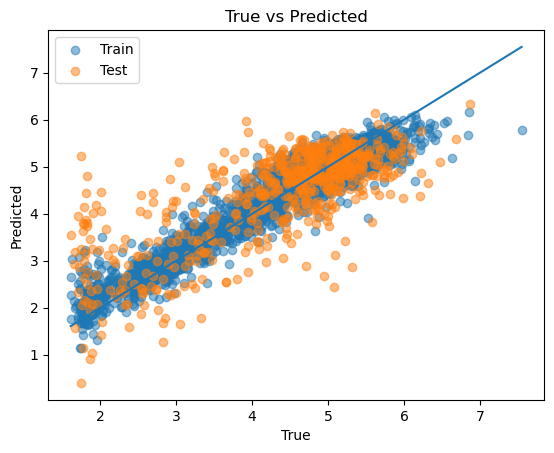

In [77]:
plt.scatter(train_y, train_pred, alpha=0.5, label="Train")
plt.scatter(test_y, test_pred, alpha=0.5, label="Test")

min_val = min(train_y.min(), test_y.min())
max_val = max(train_y.max(), test_y.max())

plt.plot([min_val, max_val], [min_val, max_val])

plt.xlabel("True")
plt.ylabel("Predicted")
plt.title("True vs Predicted")
plt.legend()

plt.show()

In [78]:
r2_score(blind_test_y, blind_test_pred)

0.0

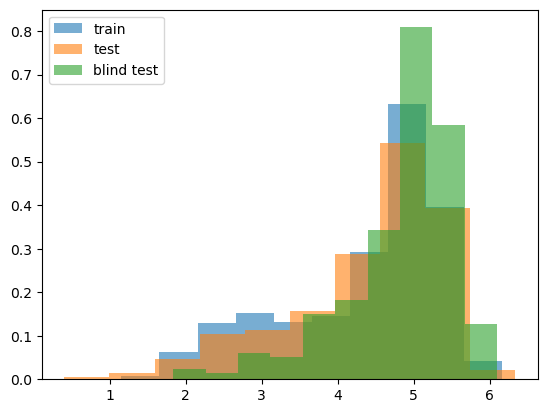

In [94]:
plt.hist(train_pred, label='train', density=True, alpha=.6)
plt.hist(test_pred, label='test', density=True, alpha=.6)
plt.hist(blind_test_pred, label='blind test', density=True, alpha=.6)
plt.legend()
plt.show()

In [ ]:
output_df = test_df[["SMILES", "Molecule Name"]].copy()
output_df["pEC50"] = blind_test_pred

In [113]:
output_df.to_csv("./wrb_ac_sub_4_22.csv", index=False)

# Training Logging

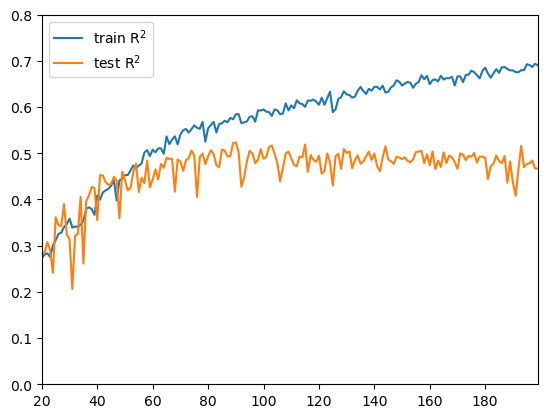

In [72]:
with open('./gnn_mlp/lc_6_6_32_2.out', 'r') as file:
    # Read all lines into a list
    lines = file.readlines()
lines = np.array([np.array(i.strip().split()).astype('float') for i in lines[1:]])

plt.plot(lines[:,0], lines[:,2], label='train R$^2$')
plt.plot(lines[:,0], lines[:,3], label='test R$^2$')
plt.xlim(20,lines[-1][0])
plt.ylim(0,.8)
plt.legend()
plt.show()

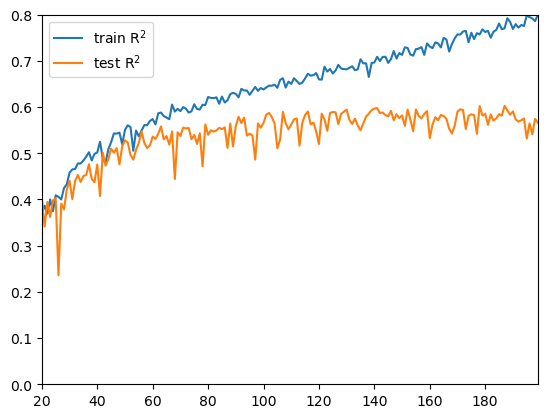

In [74]:
with open('./gnn_mlp/lc_6_6_64_2.out', 'r') as file:
    # Read all lines into a list
    lines = file.readlines()
lines = np.array([np.array(i.strip().split()).astype('float') for i in lines[1:]])

plt.plot(lines[:,0], lines[:,2], label='train R$^2$')
plt.plot(lines[:,0], lines[:,3], label='test R$^2$')
plt.xlim(20,lines[-1][0])
plt.ylim(0,.8)
plt.legend()
plt.show()

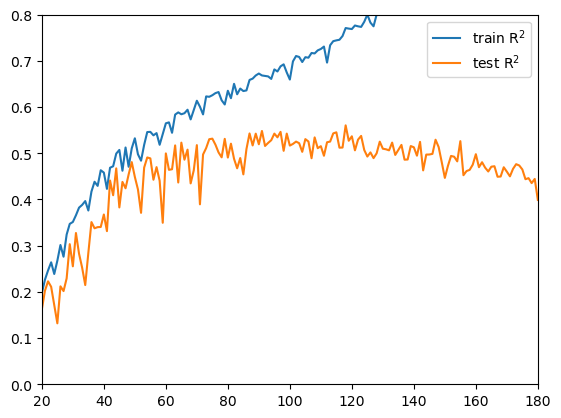

In [73]:
with open('./gnn_mlp/lc_6_6_64_4.out', 'r') as file:
    # Read all lines into a list
    lines = file.readlines()
lines = np.array([np.array(i.strip().split()).astype('float') for i in lines[1:]])

plt.plot(lines[:,0], lines[:,2], label='train R$^2$')
plt.plot(lines[:,0], lines[:,3], label='test R$^2$')
plt.xlim(20,lines[-1][0])
plt.ylim(0,.8)
plt.legend()
plt.show()

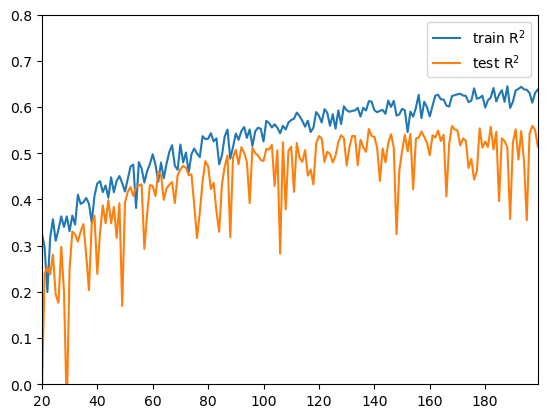

In [112]:
with open('./gnn_mlp/lc_6_6_6_32_2_unorm.out', 'r') as file:
    # Read all lines into a list
    lines = file.readlines()
lines = np.array([np.array(i.strip().split()).astype('float') for i in lines[1:]])

plt.plot(lines[:,0], lines[:,2], label='train R$^2$')
plt.plot(lines[:,0], lines[:,3], label='test R$^2$')
plt.xlim(20,lines[-1][0])
plt.ylim(0,.8)
plt.legend()
plt.show()

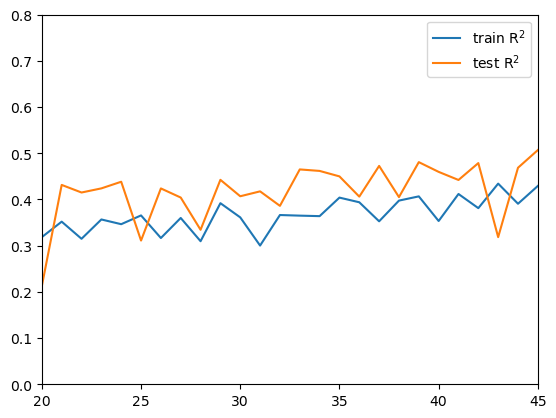

In [149]:
with open('./gnn_mlp/lc.out', 'r') as file:
    # Read all lines into a list
    lines = file.readlines()
lines = np.array([np.array(i.strip().split()).astype('float') for i in lines[1:]])

plt.plot(lines[:,0], lines[:,2], label='train R$^2$')
plt.plot(lines[:,0], lines[:,3], label='test R$^2$')
plt.xlim(20,lines[-1][0])
plt.ylim(0,.8)
plt.legend()
plt.show()

# Submit

## v1 (4/22/26 - 7:10pm)

In [4]:
import sys
from pathlib import Path

# Find the project root before importing the validation module
project_root = Path("..").resolve()
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from validation.activity_validation import validate_activity_submission

# Validate the submission file
submission_file = Path("./wrb_ac_sub_4_22.csv")

expected_activity_ids = set(test_df["Molecule Name"])
is_valid, validation_errors = validate_activity_submission(
    submission_file,
    expected_ids=expected_activity_ids,
 )

if is_valid:
    print("✅ Activity submission file is valid.")
else:
    print("❌ Activity submission file is invalid:")
    for msg in validation_errors:
        print(f" - {msg}")

✅ Activity submission file is valid.


In [115]:
from gradio_client import Client, handle_file
from huggingface_hub import get_token
from pathlib import Path

# get a token to submit
hf_token = get_token()
client = Client("openadmet/pxr-challenge", token=hf_token)

# Replace this with the path to your submission file
file_path = Path("./wrb_ac_sub_4_22.csv")

# Replace this with your own information and uncomment to submit.
result = client.predict(
   username="wborrelli",
   user_alias="wrb", # Replace if anonymous
   anon_checkbox=False, # Change to True if you want to submit anonymously
   participant_name="",
   discord_username="",
   email="",
   affiliation="",
   model_tag="",
   paper_checkbox=False,
   track_select="Activity Prediction",
   file_input=handle_file(file_path),
   api_name="/submit_predictions",
)

Loaded as API: https://openadmet-pxr-challenge.hf.space
